# Micro Proyecto 1 — Generación de Música con LSTM
Compositor seleccionado: **Ludwig van Beethoven**

In [43]:
import pretty_midi
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pygame
import time

## 1. Leer los archivos MIDI de Beethoven

In [44]:
DATA_PATH = './data/music_artist/beeth'

midi_files = sorted([os.path.join(DATA_PATH, f) for f in os.listdir(DATA_PATH) if f.endswith('.mid')])
print(f'Archivos encontrados: {len(midi_files)}')
for i, f in enumerate(midi_files):
    print(f'  [{i}] {os.path.basename(f)}')

Archivos encontrados: 29
  [0] appass_1.mid
  [1] appass_2.mid
  [2] appass_3.mid
  [3] beethoven_hammerklavier_1.mid
  [4] beethoven_hammerklavier_2.mid
  [5] beethoven_hammerklavier_3.mid
  [6] beethoven_hammerklavier_4.mid
  [7] beethoven_les_adieux_1.mid
  [8] beethoven_les_adieux_2.mid
  [9] beethoven_les_adieux_3.mid
  [10] beethoven_opus10_1.mid
  [11] beethoven_opus10_2.mid
  [12] beethoven_opus10_3.mid
  [13] beethoven_opus22_1.mid
  [14] beethoven_opus22_2.mid
  [15] beethoven_opus22_3.mid
  [16] beethoven_opus22_4.mid
  [17] beethoven_opus90_1.mid
  [18] beethoven_opus90_2.mid
  [19] elise.mid
  [20] mond_1.mid
  [21] mond_2.mid
  [22] mond_3.mid
  [23] pathetique_1.mid
  [24] pathetique_2.mid
  [25] pathetique_3.mid
  [26] waldstein_1.mid
  [27] waldstein_2.mid
  [28] waldstein_3.mid


## 2. Escuchar un archivo

In [45]:
def play_midi(filepath, seconds=15):
    """Reproduce un archivo MIDI durante 'seconds' segundos."""
    pygame.mixer.init()
    pygame.mixer.music.load(filepath)
    pygame.mixer.music.play()
    print(f'Reproduciendo: {os.path.basename(filepath)} ({seconds}s)...')
    time.sleep(seconds)
    pygame.mixer.music.stop()
    print('Listo.')

# Escuchar los primeros 15 segundos del primer archivo
# play_midi(midi_files[10], seconds=15)

## 3. Explorar un archivo

In [46]:
pm = pretty_midi.PrettyMIDI(midi_files[0])

print(f'Archivo: {os.path.basename(midi_files[0])}')
print(f'Duración: {pm.get_end_time():.2f} segundos')
print(f'Número de instrumentos: {len(pm.instruments)}')

for i, instrument in enumerate(pm.instruments):
    instrument_name = pretty_midi.program_to_instrument_name(instrument.program)
    print(f'  Instrumento {i}: {instrument_name} — {len(instrument.notes)} notas')

Archivo: appass_1.mid
Duración: 558.90 segundos
Número de instrumentos: 2
  Instrumento 0: Acoustic Grand Piano — 3207 notas
  Instrumento 1: Acoustic Grand Piano — 3170 notas


In [47]:
instrument = pm.instruments[0]
instrument_name = pretty_midi.program_to_instrument_name(instrument.program)
notes = sorted(instrument.notes, key=lambda x: x.start)

print(f'Instrumento: {instrument_name}')
print(f'\nPrimeras 10 notas (características de entrenamiento):')
print(f'{"pitch":>8} {"step":>10} {"duration":>10} {"velocity":>10}')

prev_start = None
for note in notes[:10]:
    step = note.start - prev_start if prev_start is not None else 0.0
    duration = note.end - note.start
    print(f'{note.pitch:>8} {step:>10.3f} {duration:>10.3f} {note.velocity:>10}')
    prev_start = note.start

Instrumento: Acoustic Grand Piano

Primeras 10 notas (características de entrenamiento):
   pitch       step   duration   velocity
      60      0.000      0.519         35
      56      0.519      0.137         31
      53      0.137      1.669         28
      56      1.669      0.477         35
      60      0.477      0.107         30
      65      0.107      0.528         35
      68      0.528      0.468         35
      72      0.468      0.102         30
      77      0.102      0.559         35
      65      0.567      0.556         33


## 4. Extraer las características de todos los archivos

Por cada nota extraemos:
- **pitch**: nota musical (categórica)
- **step**: tiempo desde la nota anterior (start_actual - start_anterior)
- **duration**: duración de la nota (end - start)
- **velocity**: velocidad de la nota (numérica)

In [48]:
def extract_notes(instrument):
    notes = sorted(instrument.notes, key=lambda x: x.start)
    
    rows = []
    prev_start = None
    for note in notes:
        duration = note.end - note.start
        step = note.start - prev_start if prev_start is not None else 0.0
        rows.append({
            'pitch': note.pitch,
            'step': step,
            'duration': duration,
            'velocity': note.velocity
        })
        prev_start = note.start
    return rows

all_notes = []
sequences = []  # lista de DataFrames, uno por secuencia (instrumento x archivo)

for mid, f in enumerate(midi_files):
    pm = pretty_midi.PrettyMIDI(f)
    for i, instrument in enumerate(pm.instruments):
        notes = extract_notes(instrument)
        seq_df = pd.DataFrame(notes)
        sequences.append(seq_df)
        all_notes.extend(notes)
        if mid < 3: 
            print(f'{os.path.basename(f)} — instrumento {i}: {len(notes)} notas')

df = pd.DataFrame(all_notes)
print(f'\nTotal de secuencias: {len(sequences)}')
print(f'Total de notas: {len(df)}')
df.head(10)

appass_1.mid — instrumento 0: 3207 notas
appass_1.mid — instrumento 1: 3170 notas
appass_2.mid — instrumento 0: 1128 notas
appass_2.mid — instrumento 1: 853 notas
appass_3.mid — instrumento 0: 3742 notas
appass_3.mid — instrumento 1: 3481 notas

Total de secuencias: 62
Total de notas: 111205


,pitch,step,duration,velocity
0,60,0.000000,0.518640,35
1,56,0.518640,0.136599,31
2,53,0.136599,1.669347,28
3,56,1.669347,0.477331,35
4,60,0.477331,0.107427,30
5,65,0.107427,0.528293,35
6,68,0.528293,0.468093,35
7,72,0.468093,0.101550,30
8,77,0.101550,0.558752,35
9,65,0.566917,0.556449,33


## 5. Análisis Exploratorio de Datos (EDA)

In [49]:
# --- 5.1 Instrumentos por archivo ---
print(f'{"Archivo":<35} {"N° inst":>7}  Instrumentos')
print('-' * 70)

instrument_types = []
notes_per_file = []

for f in midi_files:
    pm = pretty_midi.PrettyMIDI(f)
    names = [pretty_midi.program_to_instrument_name(inst.program) for inst in pm.instruments]
    notes_count = sum(len(inst.notes) for inst in pm.instruments)
    notes_per_file.append(notes_count)
    instrument_types.extend(names)
    print(f'{os.path.basename(f):<35} {len(pm.instruments):>7}  {", ".join(names)}')

print(f'\nTipos de instrumento únicos en todo el dataset: {set(instrument_types)}')
print(f'Total de archivos: {len(midi_files)}')
print(f'Total de secuencias (archivos × instrumentos): {len(sequences)}')

Archivo                             N° inst  Instrumentos
----------------------------------------------------------------------
appass_1.mid                              2  Acoustic Grand Piano, Acoustic Grand Piano
appass_2.mid                              2  Acoustic Grand Piano, Acoustic Grand Piano
appass_3.mid                              2  Acoustic Grand Piano, Acoustic Grand Piano
beethoven_hammerklavier_1.mid             2  Acoustic Grand Piano, Acoustic Grand Piano
beethoven_hammerklavier_2.mid             2  Acoustic Grand Piano, Acoustic Grand Piano
beethoven_hammerklavier_3.mid             2  Acoustic Grand Piano, Acoustic Grand Piano
beethoven_hammerklavier_4.mid             2  Acoustic Grand Piano, Acoustic Grand Piano
beethoven_les_adieux_1.mid                2  Acoustic Grand Piano, Acoustic Grand Piano
beethoven_les_adieux_2.mid                2  Acoustic Grand Piano, Acoustic Grand Piano
beethoven_les_adieux_3.mid                2  Acoustic Grand Piano, Acoustic Gra

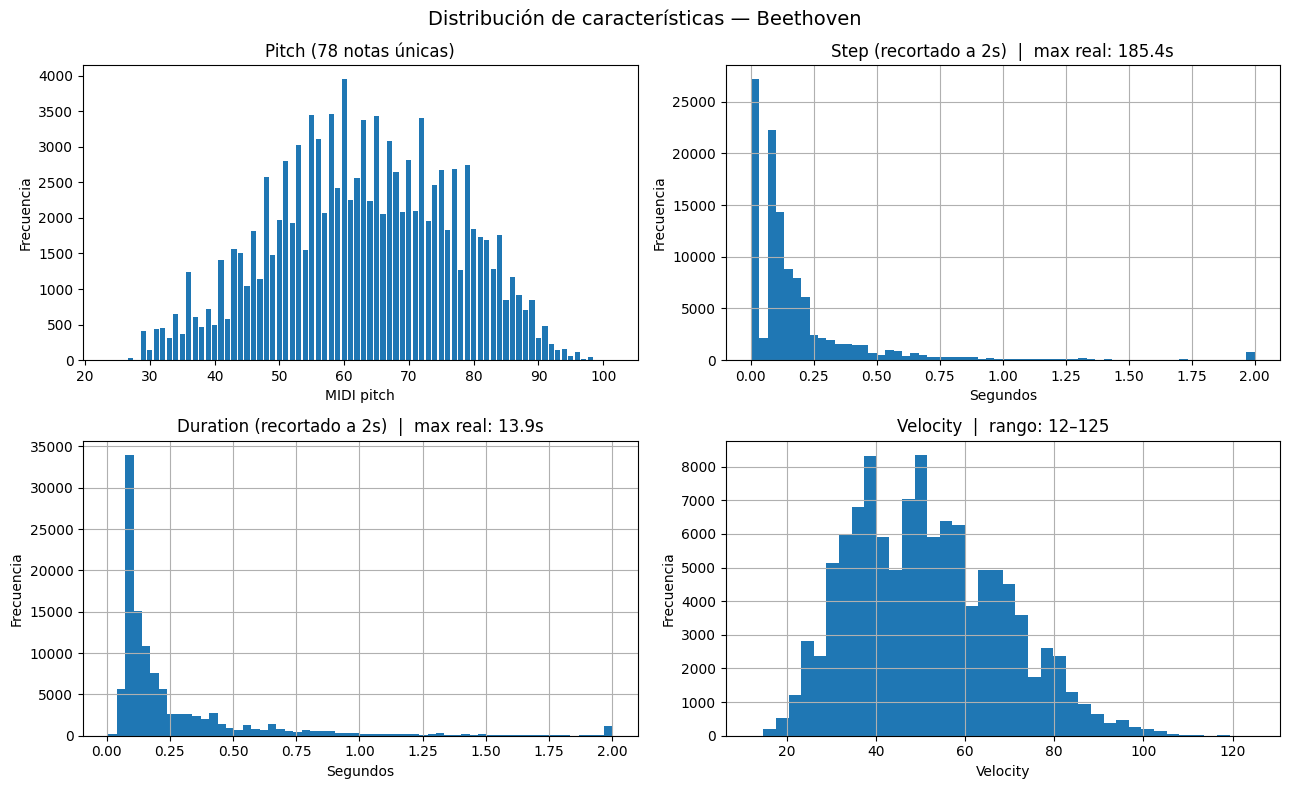


Estadísticas descriptivas:
            pitch        step    duration    velocity
count  111205.000  111205.000  111205.000  111205.000
mean       62.948       0.207       0.284      51.669
std        13.914       0.955       0.425      16.743
min        24.000       0.000       0.007      12.000
25%        53.000       0.055       0.096      38.000
50%        63.000       0.105       0.140      50.000
75%        74.000       0.204       0.296      63.000
max       101.000     185.374      13.944     125.000


In [50]:
# --- 5.3 Distribución de las 4 características ---
fig, axes = plt.subplots(2, 2, figsize=(13, 8))
fig.suptitle('Distribución de características — Beethoven', fontsize=14)

# Pitch: frecuencia de cada nota
pitch_counts = df['pitch'].value_counts().sort_index()
axes[0, 0].bar(pitch_counts.index, pitch_counts.values, width=0.8)
axes[0, 0].set_title(f'Pitch ({df["pitch"].nunique()} notas únicas)')
axes[0, 0].set_xlabel('MIDI pitch')
axes[0, 0].set_ylabel('Frecuencia')

# Step: recortado para ver la distribución sin outliers extremos
df['step'].clip(0, 2).hist(ax=axes[0, 1], bins=60, edgecolor='none')
axes[0, 1].set_title(f'Step (recortado a 2s)  |  max real: {df["step"].max():.1f}s')
axes[0, 1].set_xlabel('Segundos')
axes[0, 1].set_ylabel('Frecuencia')

# Duration
df['duration'].clip(0, 2).hist(ax=axes[1, 0], bins=60, edgecolor='none')
axes[1, 0].set_title(f'Duration (recortado a 2s)  |  max real: {df["duration"].max():.1f}s')
axes[1, 0].set_xlabel('Segundos')
axes[1, 0].set_ylabel('Frecuencia')

# Velocity
df['velocity'].hist(ax=axes[1, 1], bins=40, edgecolor='none')
axes[1, 1].set_title(f'Velocity  |  rango: {df["velocity"].min()}–{df["velocity"].max()}')
axes[1, 1].set_xlabel('Velocity')
axes[1, 1].set_ylabel('Frecuencia')

plt.tight_layout()
plt.show()

print('\nEstadísticas descriptivas:')
print(df.describe().round(3))

In [ ]:
# --- 5.4 Piano roll de una composición de ejemplo ---
pm_example = pretty_midi.PrettyMIDI(midi_files[0])
instrument_example = pm_example.instruments[0]
notes_example = sorted(instrument_example.notes, key=lambda x: x.start)

# Mostrar solo los primeros 30 segundos
cutoff = 30
notes_plot = [n for n in notes_example if n.start < cutoff]

fig, ax = plt.subplots(figsize=(14, 4))
for note in notes_plot:
    ax.barh(note.pitch, note.end - note.start, left=note.start,
            height=0.8, color='steelblue', alpha=0.7)

ax.set_xlabel('Tiempo (segundos)')
ax.set_ylabel('MIDI Pitch')
ax.set_title(f'Piano roll — {os.path.basename(midi_files[0])} (primeros {cutoff}s, instrumento 0)')
ax.set_xlim(0, cutoff)
plt.tight_layout()
plt.show()

## 6. Preparación del dataset para entrenamiento

In [ ]:
import torch
from sklearn.preprocessing import MinMaxScaler

# --- 6.1 Split train / test al nivel de secuencia ---
# Se hace el split por secuencia (no por nota) para que el modelo
# se evalúe en composiciones completas que nunca vio durante el entrenamiento.
np.random.seed(42)
n_sequences = len(sequences)
idx_all = np.random.permutation(n_sequences)
split = int(n_sequences * 0.8)

train_seqs = [sequences[i] for i in idx_all[:split]]
test_seqs  = [sequences[i] for i in idx_all[split:]]

print(f'Total de secuencias: {n_sequences}')
print(f'  Train: {len(train_seqs)} secuencias  ({sum(len(s) for s in train_seqs):,} notas)')
print(f'  Test:  {len(test_seqs)} secuencias  ({sum(len(s) for s in test_seqs):,} notas)')

In [ ]:
# --- 6.2 Normalización ---
# pitch  → se deja como entero (0-127) para usarlo en un Embedding
# step, duration, velocity → MinMaxScaler ajustado SOLO con datos de train

scaler = MinMaxScaler()
train_continuous = pd.concat(train_seqs)[['step', 'duration', 'velocity']]
scaler.fit(train_continuous)

def normalize_seq(seq_df, scaler):
    """Devuelve un array (N, 4): [pitch_int, step_norm, duration_norm, velocity_norm]"""
    arr = seq_df.copy()
    arr[['step', 'duration', 'velocity']] = scaler.transform(arr[['step', 'duration', 'velocity']])
    return arr.values  # (N, 4)

train_arrays = [normalize_seq(s, scaler) for s in train_seqs]
test_arrays  = [normalize_seq(s, scaler) for s in test_seqs]

print('Ejemplo de una nota normalizada:')
print(f'  [pitch, step_norm, duration_norm, velocity_norm]')
print(f'  {train_arrays[0][0]}')

In [ ]:
# --- 6.3 DataLoader ---
# Inspirado en el DataLoader del laboratorio, adaptado para:
#   - Múltiples secuencias (una por instrumento/canción)
#   - 4 features por nota en lugar de 1 token
#   - Nunca cruzar el límite entre secuencias
#
# Cada ejemplo: x = (block_size, 4), y = (4,)  → predice la siguiente nota

class MusicDataLoader:
    def __init__(self, sequences, block_size):
        """
        sequences : lista de arrays numpy (N_i, 4) — una por canción/instrumento
        block_size: tamaño del contexto (número de notas de entrada)
        """
        self.block_size = block_size
        self.sequences  = [torch.tensor(s, dtype=torch.float32) for s in sequences]

        # Pre-calcular todos los índices válidos (seq_idx, start_note)
        # Una ventana es válida si hay al menos block_size+1 notas desde start_note
        self.indices = []
        for seq_idx, seq in enumerate(self.sequences):
            for start in range(len(seq) - block_size):
                self.indices.append((seq_idx, start))

        self.order    = np.random.permutation(len(self.indices))
        self.curr_pos = 0

    def get_batch(self, batch_size):
        batch_idx = self.order[self.curr_pos : self.curr_pos + batch_size]
        self.curr_pos += len(batch_idx)

        # Cuando se agota el dataset, se reordena y se reinicia
        if len(batch_idx) < batch_size:
            self.curr_pos = 0
            self.order = np.random.permutation(len(self.indices))
            if len(batch_idx) == 0:
                batch_idx = self.order[:batch_size]
                self.curr_pos = batch_size

        xs, ys = [], []
        for i in batch_idx:
            seq_idx, start = self.indices[i]
            seq = self.sequences[seq_idx]
            xs.append(seq[start : start + self.block_size])   # (block_size, 4)
            ys.append(seq[start + self.block_size])           # (4,)

        x = torch.stack(xs)   # (batch_size, block_size, 4)
        y = torch.stack(ys)   # (batch_size, 4)
        return x, y

    @property
    def n_examples(self):
        return len(self.indices)


BLOCK_SIZE = 25
BATCH_SIZE = 64

train_loader = MusicDataLoader(train_arrays, block_size=BLOCK_SIZE)
test_loader  = MusicDataLoader(test_arrays,  block_size=BLOCK_SIZE)

print(f'Block size (contexto): {BLOCK_SIZE} notas')
print(f'Batch size:            {BATCH_SIZE}')
print(f'Ventanas de entrenamiento: {train_loader.n_examples:,}')
print(f'Ventanas de test:          {test_loader.n_examples:,}')

# Verificar forma de un lote
x, y = train_loader.get_batch(BATCH_SIZE)
print(f'\nForma de un lote:')
print(f'  x: {tuple(x.shape)}  → (batch, contexto, features)')
print(f'  y: {tuple(y.shape)}  → (batch, features)')